# Численный метод
## Тригонометрические ряды Фурье, вариант 90

Исходная функция: $f(x)=x/2$ при $x \in [0, 2)$ и $f(x)=1$ при $x \in [2, 4]$.

Во второй части нужно построить графики частичных сумм общего ряда Фурье, ряда по косинусам и ряда по синусам, а также пояснить, как сумма ряда связана с исходной функцией.


### Импорт библиотек и создание функций


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams["figure.figsize"] = (11, 4.5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.3

pi = np.pi


def f(x):
    x = np.asarray(x, dtype=float)
    return np.where(x < 2, x / 2, 1.0)


def series_sum(x, terms):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float) + 3.0 / 4.0

    for n in range(1, terms + 1):
        a_n = (((-1) ** n) - 1) / (pi ** 2 * n ** 2)
        b_n = -1 / (pi * n)
        y += a_n * np.cos(pi * n * x / 2) + b_n * np.sin(pi * n * x / 2)

    return y


def cos_series_sum(x, terms):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float) + 3.0 / 4.0

    for k in range(1, terms + 1):
        a_k = 4 * (np.cos(pi * k / 2) - 1) / (pi ** 2 * k ** 2)
        y += a_k * np.cos(pi * k * x / 4)

    return y


def sin_series_sum(x, terms):
    x = np.asarray(x, dtype=float)
    y = np.zeros_like(x, dtype=float)

    for k in range(1, terms + 1):
        b_k = 4 * np.sin(pi * k / 2) / (pi ** 2 * k ** 2) - 2 * (-1) ** k / (pi * k)
        y += b_k * np.sin(pi * k * x / 4)

    return y


def general_limit(x):
    x = np.asarray(x, dtype=float)
    x_mod = np.mod(x, 4.0)
    y = np.where(x_mod < 2, x_mod / 2, 1.0)
    y = np.where(np.isclose(x_mod, 0.0), 0.5, y)
    return y


def even_limit(x):
    x = np.asarray(x, dtype=float)
    x_periodic = ((x + 4.0) % 8.0) - 4.0
    return np.where(np.abs(x_periodic) < 2, np.abs(x_periodic) / 2, 1.0)


def odd_limit(x):
    x = np.asarray(x, dtype=float)
    x_periodic = ((x + 4.0) % 8.0) - 4.0
    y = np.where(np.abs(x_periodic) < 2, np.abs(x_periodic) / 2, 1.0)
    y = np.sign(x_periodic) * y
    y = np.where(np.isclose(np.mod(x, 4.0), 0.0), 0.0, y)
    return y


## 1, 3. Частичные суммы рядов из первой части

Для построения графиков удобно использовать уже упрощённые формулы:

- $S_N(x)=3/4+\sum_{n=1}^{N}\left(((-1)^n-1)/(\pi^2 n^2)\cdot \cos(\pi n x/2)-\sin(\pi n x/2)/(\pi n)\right)$
- $E_N(x)=3/4+\sum_{k=1}^{N}\left(4(\cos(\pi k/2)-1)/(\pi^2 k^2)\cdot \cos(\pi k x/4)\right)$
- $O_N(x)=\sum_{k=1}^{N}\left(4\sin(\pi k/2)/(\pi^2 k^2)-2(-1)^k/(\pi k)\right)\cdot \sin(\pi k x/4)$

Ниже строим графики для `N = 3, 10, 30`.


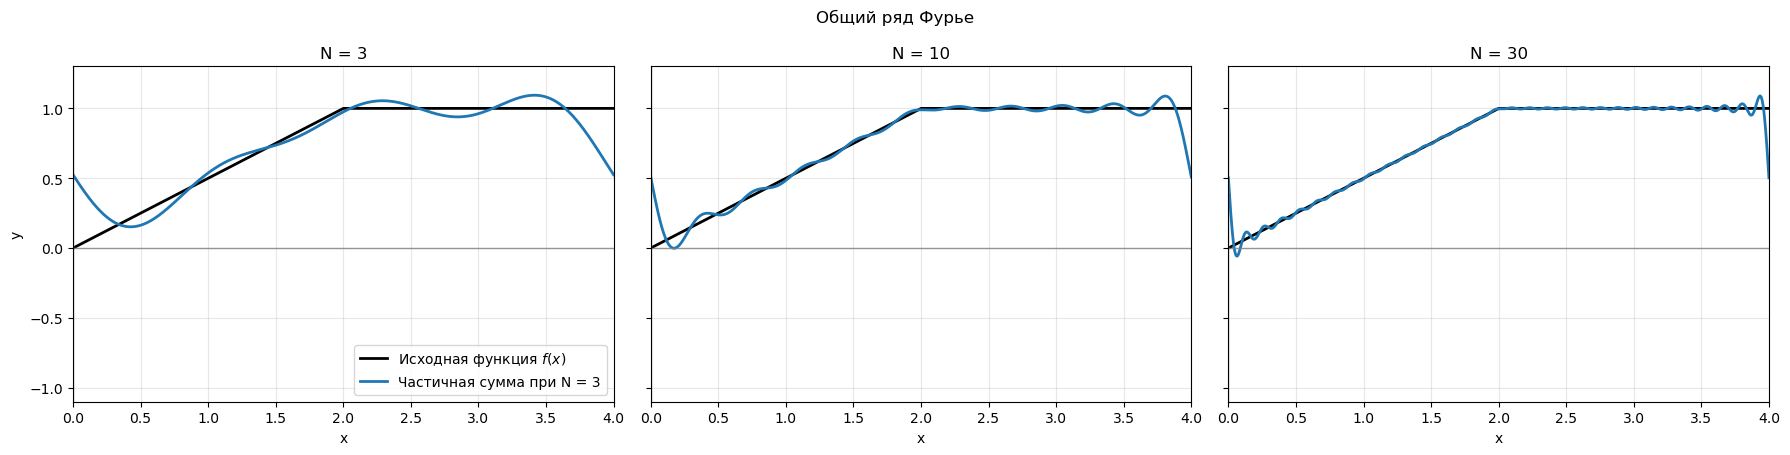

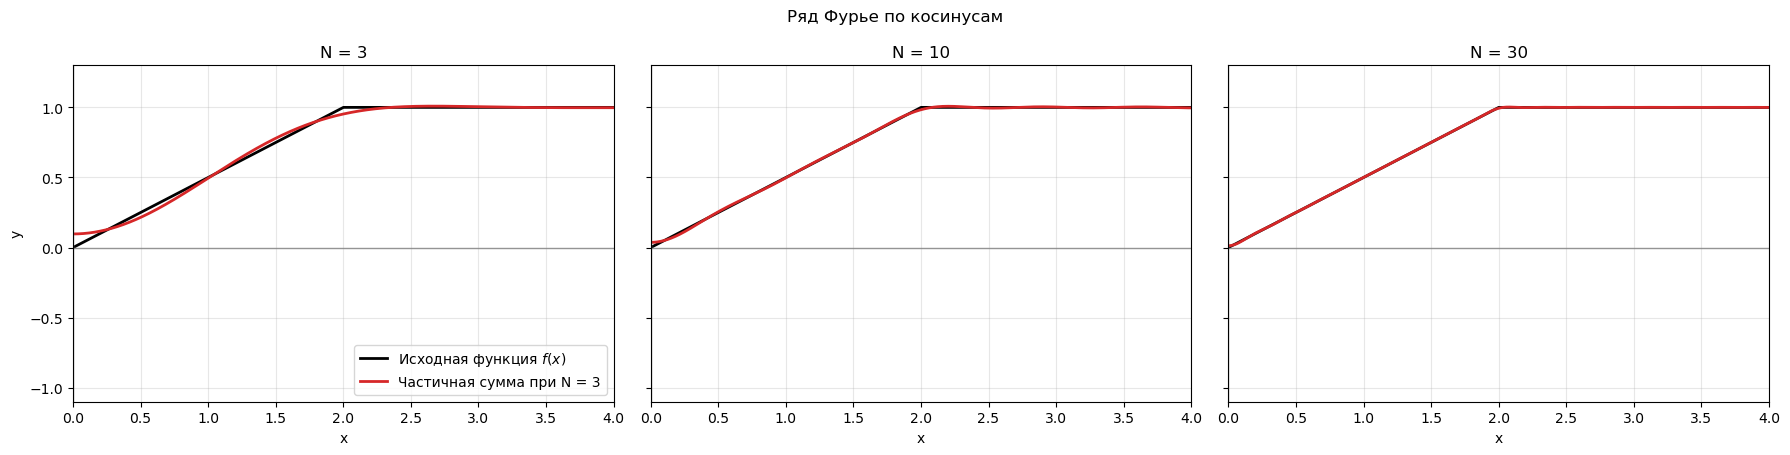

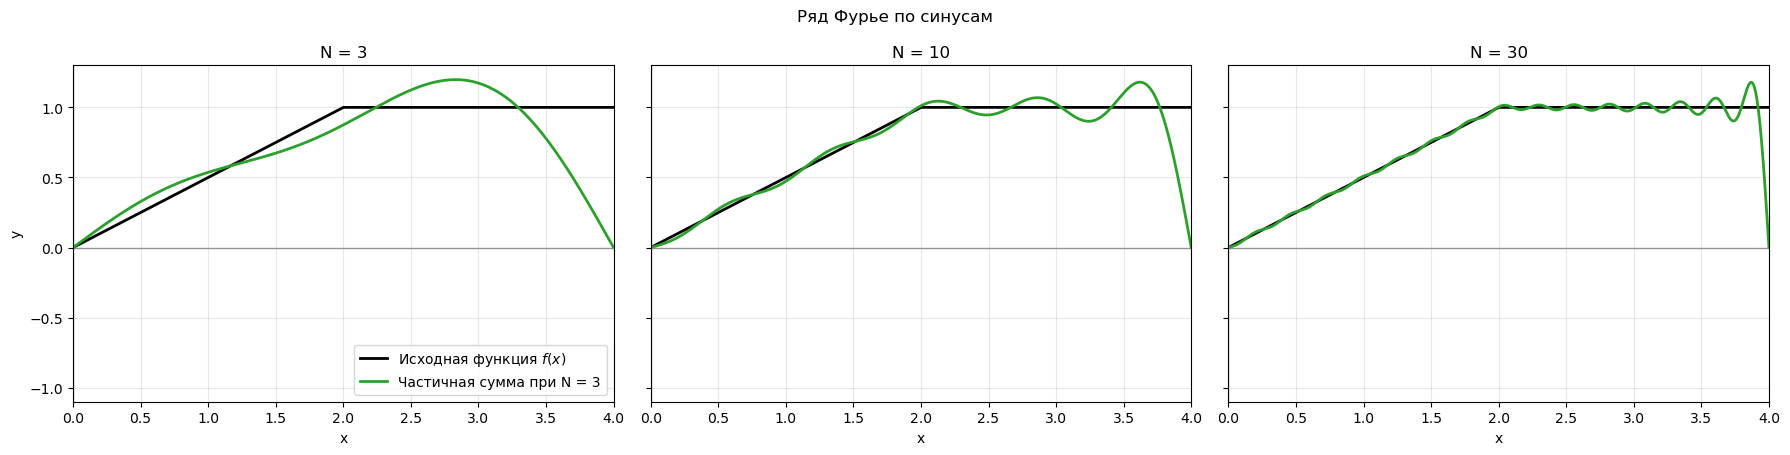

In [ ]:
x_segment = np.linspace(0, 4, 2000)
plot_counts = [3, 10, 30]

series_map = [
    ("Общий ряд Фурье", series_sum, "tab:blue"),
    ("Ряд Фурье по косинусам", cos_series_sumtab:red"),
    ("Ряд Фурье по синусам", sin_series_sum "tab:green"),
]


def plot_series_family(title, series_function, color):
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.6), sharey=True)

    for ax, terms in zip(axes, plot_counts):
        ax.plot(x_segment, f(x_segment), color="black", linewidth=2, label="Исходная функция $f(x)$")
        ax.plot(
            x_segment,
            series_function(x_segment, terms),
            color=color,
            linewidth=2,
            label=f"Частичная сумма при N = {terms}",
        )
        ax.set_title(f"N = {terms}")
        ax.set_xlim(0, 4)
        ax.set_ylim(-1.1, 1.3)
        ax.axhline(0, color="gray", linewidth=1, alpha=0.8)
        ax.axvline(0, color="gray", linewidth=1, alpha=0.8)
        ax.set_xlabel("x")

    axes[0].set_ylabel("y")
    axes[0].legend(loc="lower right")
    fig.suptitle(title)
    fig.tight_layout()
    plt.show()


for title, series_function, color in series_map:
    plot_series_family(title, series_function, color)


## 2. Как связаны сумма ряда и исходная функция?

1. Общий ряд Фурье совпадает с периодическим продолжением исходной функции. На интервале $(0, 4)$ сумма ряда равна $f(x)$, а в точках разрыва $x = 4k$ она равна среднему арифметическому односторонних пределов:

$S(4k)=(1+0)/2=1/2$

2. Ряд по косинусам совпадает с чётным продолжением функции на всю прямую. Для нашей функции это продолжение непрерывно в точках $x=0$ и $x=4$, поэтому на отрезке $[0, 4]$ сумма косинусного ряда совпадает с исходной функцией во всех точках.

3. Ряд по синусам совпадает с нечётным 8-периодическим продолжением. На интервале $(0, 4)$ он тоже совпадает с $f(x)$ но в точках $x = 4k$ принимает значение

$O(4k)=(1+(-1))/2=0$

### Итог: внутри отрезка $(0, 4)$ все три ряда стремятся к исходной функции, а различаются только на границе и вне отрезка - т.к. используют разные продолжения.

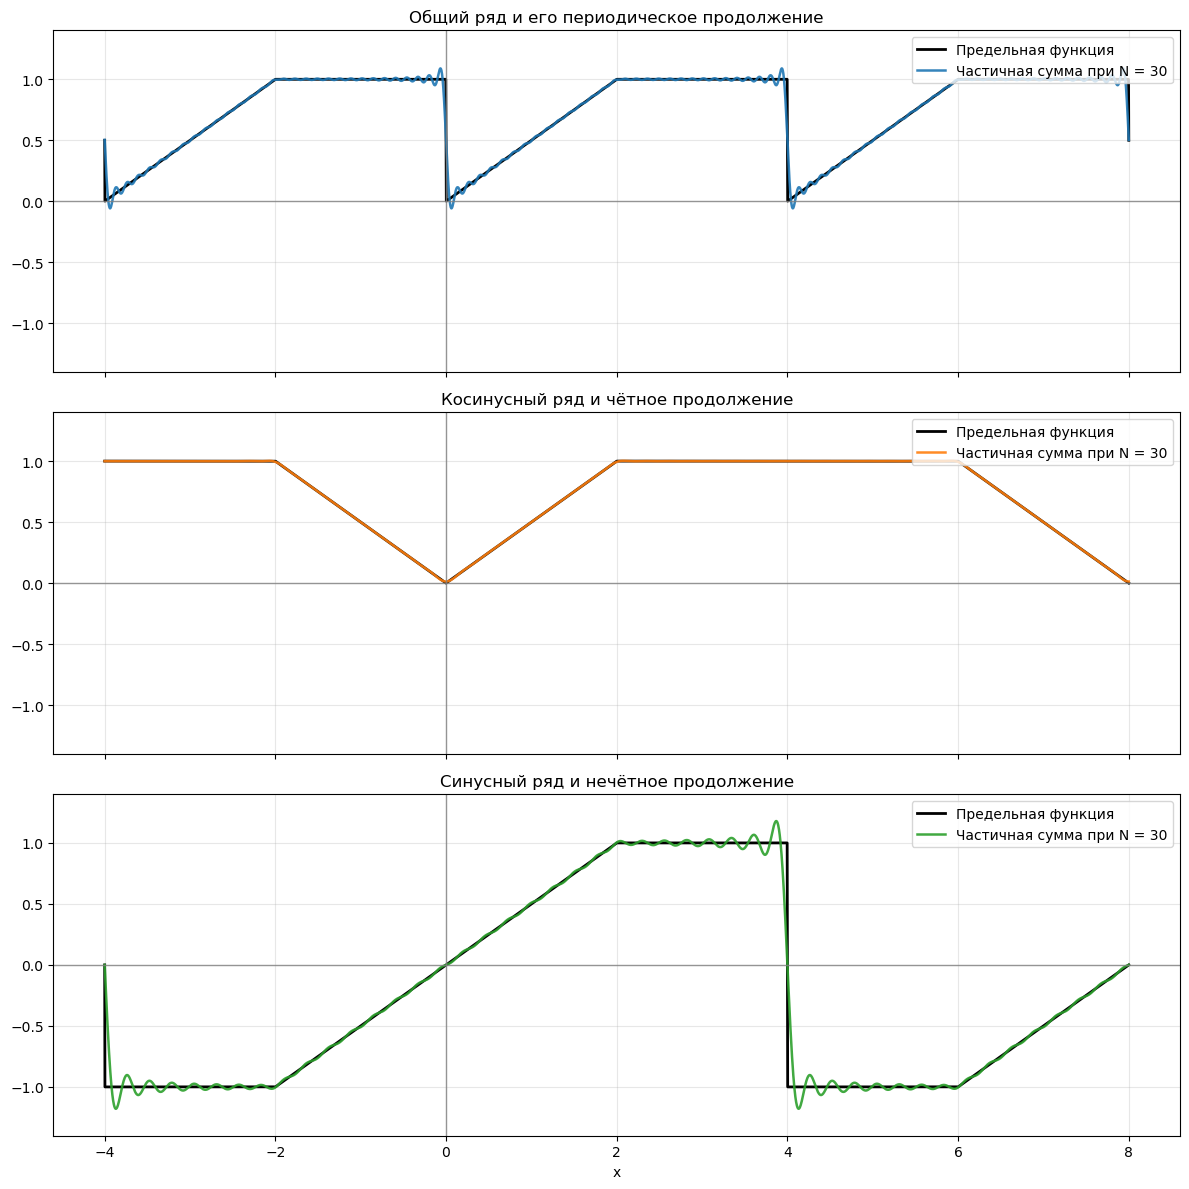

In [ ]:
x_extended = np.linspace(-4, 8, 4000)
terms = 30

extended_plots = [
    ("Общий ряд и его периодическое продолжение", series_sum, general_limit, "tab:blue"),
    ("Косинусный ряд и чётное продолжение", cos_series_sum_limit, "tab:orange"),
    ("Синусный ряд и нечётное продолжение", sin_series_sumodd_limit, "tab:green"),
]

fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

for ax, (title, partial_sum, limit_function, color) in zip(axes, extended_plots):
    ax.plot(x_extended, limit_function(x_extended), color="black", linewidth=2, label="Предельная функция")
    ax.plot(
        x_extended,
        partial_sum(x_extended, terms),
        color=color,
        linewidth=1.8,
        alpha=0.9,
        label=f"Частичная сумма при N = {terms}",
    )
    ax.set_title(title)
    ax.set_ylim(-1.4, 1.4)
    ax.axhline(0, color="gray", linewidth=1, alpha=0.8)
    ax.axvline(0, color="gray", linewidth=1, alpha=0.8)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("x")
fig.tight_layout()
plt.show()
